# Description

This notebook will create a version of the Powers 264 altas that only contains ROIs common to the FOV of all datasets part of the Gating / Non-Gating dataset. 

This is the dataset that we use in the first part of the paper to describe our quality metrics

In [1]:
from nilearn.datasets import fetch_coords_power_2011
from utils.basics import ATLASES_DIR
import os
import os.path as osp
import pandas as pd

In [2]:
sbj_list = ['MGSBJ01',  'MGSBJ02',  'MGSBJ03',  'MGSBJ04',  'MGSBJ05',  'MGSBJ06',  'MGSBJ07']
ses_list = ['constant_gated', 'cardiac_gated']

# 1. Download ROI centers for Powers 264 altas using nilearn

In [3]:
power_atlas_info = fetch_coords_power_2011(False)

In [4]:
power_atlas_info['rois'].head(5)

,roi,x,y,z
0,1,-25,-98,-12
1,2,27,-97,-13
2,3,24,32,-18
3,4,-56,-45,-24
4,5,8,41,-24


# 2. Create Folder for Dataset-specific version of Powers 264 atlas

In [5]:
ATLAS_NAME='Power264-discovery'
ATLAS_DIR = osp.join(ATLASES_DIR,ATLAS_NAME)
print(ATLAS_DIR)

/data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery


In [6]:
if not osp.exists(ATLAS_DIR):
    os.makedirs(ATLAS_DIR)
    os.symlink(osp.join(ATLASES_DIR,'Power264','additional_files'),osp.join(ATLAS_DIR,'additional_files'))

# 3. Write ROI centroids to disk as csv file

In [7]:
roi_centers_path = osp.join(ATLAS_DIR,f'{ATLAS_NAME}.roi_coords.MNI.csv')
power_atlas_info['rois'][['x','y','z','roi']].to_csv(roi_centers_path, header=None, index=None)
print("++ INFO: ROI Coordinates saved to disk [%s]" % roi_centers_path)

++ INFO: ROI Coordinates saved to disk [/data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery/Power264-discovery.roi_coords.MNI.csv]


# 4. Add ROI Names and other info needed for plotting

In [8]:
roi_info_df = power_atlas_info['rois'].copy()
roi_info_df.columns = ['ROI_ID','pos_A','pos_R','pos_S']
roi_info_df['ROI_Name'] = ['ROI'+str(r).zfill(3) for r in roi_info_df['ROI_ID']]
roi_info_df = roi_info_df[['ROI_ID','ROI_Name','pos_A','pos_R','pos_S']]
print(roi_info_df.shape)
roi_info_df.head(5)

(264, 5)


,ROI_ID,ROI_Name,pos_A,pos_R,pos_S
0,1,ROI001,-25,-98,-12
1,2,ROI002,27,-97,-13
2,3,ROI003,24,32,-18
3,4,ROI004,-56,-45,-24
4,5,ROI005,8,41,-24


In [9]:
color_map_dict={'White':'#ffffff','Cyan':'#E0FFFF','Orange':'#FFA500','Purple':'#800080',
                'Pink':'#FFC0CB','Red':'#ff0000','Gray':'#808080','Teal':'#008080','Brown':'#A52A2A',
                'Blue':'#0000ff','Yellow':'#FFFF00','Black':'#000000','Pale blue':'#ADD8E6','Green':'#00ff00'}
nw_color_dict = {'Uncertain':'#ffffff',
                 'Sensory/somatomotor Hand':'#E0FFFF',
                 'Sensory/somatomotor Mouth':'#FFA500',
                 'Cingulo-opercular Task Control':'#800080',
                 'Auditory':'#FFC0CB',
                 'Default mode':'#ff0000',
                 'Memory retrieval?':'#808080',
                 'Ventral attention':'#008080',
                 'Visual':'#0000ff',
                 'Fronto-parietal Task Control':'#FFFF00',
                 'Salience':'#000000',
                 'Subcortical':'#A52A2A',
                 'Cerebellar':'#ADD8E6',
                 'Dorsal attention':'#00ff00'}

power_atlas_addinfo_path = osp.join(ATLAS_DIR,'additional_files','Neuron_consensus_264.xlsx')
power_atlas_addinfo = pd.read_excel(power_atlas_addinfo_path, header=[0], skiprows=[1])

roi_info_df['Network']= power_atlas_addinfo['Suggested System']
roi_info_df['Hemisphere'] = ['LH' if a<=0 else 'RH' for a in roi_info_df['pos_R']]
roi_info_df['RGB'] = [color_map_dict[c] for c in power_atlas_addinfo['Unnamed: 34']]
roi_info_df.head(5)

/data/SFIMJGC_HCP7T/Apps/envs/bold_waves_2024a/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,ROI_ID,ROI_Name,pos_A,pos_R,pos_S,Network,Hemisphere,RGB
0,1,ROI001,-25,-98,-12,Uncertain,LH,#ffffff
1,2,ROI002,27,-97,-13,Uncertain,LH,#ffffff
2,3,ROI003,24,32,-18,Uncertain,RH,#ffffff
3,4,ROI004,-56,-45,-24,Uncertain,LH,#ffffff
4,5,ROI005,8,41,-24,Uncertain,RH,#ffffff


# 5. Create first version (still need to check for FOV) as NIFTI file

```bash
    ml afni
    cd /data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery
    3dUndump -overwrite \
             -prefix Power264-discovery.nii.gz \
             -master ../../prcs_data/MGSBJ01/D03_Preproc_cardiac_gated_NORDIC-off/errts.MGSBJ01.fanaticor+tlrc.HEAD \
             -xyz \
             -srad 5 \
             -xyz Power264-discovery.roi_coords.MNI.csv
```

# 6. Create FOV masks for each dataset

In [10]:
from utils.basics import PRCS_DATA_DIR, PRJ_DIR, CODE_DIR
import datetime
import getpass
import subprocess
username = getpass.getuser()
print(username)

javiergc


Create path for swarm file

In [11]:
script_path = osp.join(PRJ_DIR,f'swarm.{username}',f'N02b_check_sample_FOV_vs_atlas.{ATLAS_NAME}.swarm.sh')
print(script_path)

/data/SFIMJGC_HCP7T/BCBL2024/swarm.javiergc/N02b_check_sample_FOV_vs_atlas.Power264-discovery.swarm.sh


Create folder for swarm log files

In [12]:
log_path = osp.join(PRJ_DIR,f'logs.{username}',f'N02b_check_sample_FOV_vs_atlas.{ATLAS_NAME}.log')
if not osp.exists(log_path):
    os.makedirs(log_path)
print(log_path)

/data/SFIMJGC_HCP7T/BCBL2024/logs.javiergc/N02b_check_sample_FOV_vs_atlas.Power264-discovery.log


Create swarm file (one line per scan)

In [13]:
with open(script_path, 'w') as the_file:
    the_file.write('# Script Creation Date: %s\n' % str(datetime.date.today()))
    the_file.write(f'# swarm -f {script_path} -g 16 -t 8 -b 5 --time 00:20:00 --logdir {log_path} --partition quick,norm --module afni\n')
    the_file.write('\n')
    for sbj in sbj_list:
        for ses in ses_list:
            the_file.write(f'cd {PRCS_DATA_DIR}/{sbj}/D03_Preproc_{ses}_NORDIC-off; 3dcalc -overwrite -a tedana_fastica/adaptive_mask.nii.gz -expr "step(a)" -prefix mask_tedana_at_least_one_echo.nii.gz; 3dcalc -overwrite -a tedana_fastica/adaptive_mask.nii.gz -expr "equals(a,3)" -prefix mask_tedana_allechoes.nii.gz; 3drefit -space MNI mask_tedana_at_least_one_echo.nii.gz; 3drefit -space MNI mask_tedana_allechoes.nii.gz; 3dNetCorr -overwrite -in_rois {ATLASES_DIR}/{ATLAS_NAME}/{ATLAS_NAME}.nii.gz -output_mask_nonnull -inset pb04.{sbj}.r01.combine+tlrc.HEAD -prefix rm.{sbj}.combine.{ATLAS_NAME}.FOVcheck \n')
the_file.close()     

In [14]:
script_path

'/data/SFIMJGC_HCP7T/BCBL2024/swarm.javiergc/N02b_check_sample_FOV_vs_atlas.Power264-discovery.swarm.sh'

For this dataset, because the number of scans is so small, it might be ok to just run it a console. That said, if you want to still parallelize, here is the swarm call

```bash
swarm -f /data/SFIMJGC_HCP7T/BCBL2024/swarm.javiergc/N02b_check_sample_FOV_vs_atlas.Power264-discovery.sh -g 16 -t 8 -b 5 --time 00:10:00 --logdir /data/SFIMJGC_HCP7T/BCBL2024/logs.javiergc/N02b_check_sample_FOV_vs_atlas.Power264-discovery.log --partition quick,norm --module afni
```

# 7. Ensure all necessary files were created by the swarm job

In [15]:
for sbj in sbj_list:
    for ses in ses_list:
        expected_output_path = osp.join(PRCS_DATA_DIR,sbj,f'D03_Preproc_{ses}_NORDIC-off',f'rm.{sbj}.combine.{ATLAS_NAME}.FOVcheck_mask_nnull+tlrc.HEAD')
        if not osp.exists(expected_output_path):
            print('++ WARNING: %s is missing' % expected_output_path)

# 8. See which ROIs do not have at least 5% overlap with the imaging FOV of any subject

In [16]:
bad_roi_list = []
for sbj in sbj_list:
    for ses in ses_list:
        roidat_path       = osp.join(PRCS_DATA_DIR,sbj,f'D03_Preproc_{ses}_NORDIC-off',f'rm.{sbj}.combine.{ATLAS_NAME}.FOVcheck_000.roidat')
        roidat_df         = pd.read_csv(roidat_path,sep=' ', skipinitialspace=True, header=0)
        correct_columns   = roidat_df.columns.drop(['#'])
        roidat_df         = roidat_df.drop(['ROI_label'],axis=1)
        roidat_df.columns = correct_columns
        roidat_df         = roidat_df.drop(['#.1'],axis=1)
        bad_rois          = roidat_df[(roidat_df['frac']<=0.05) | (roidat_df['N_nonnull']<10)][['ROI','ROI_label']]
        if bad_rois.shape[0] > 0:
            print('++ INFO: %s/%s --> Number of Bad Rois: %d' % (sbj,ses,bad_rois.shape[0]), end=' | ')
        for i,br in bad_rois.iterrows():
            bad_roi_list.append((br['ROI'],br['ROI_label']))

++ INFO: MGSBJ01/constant_gated --> Number of Bad Rois: 20 | ++ INFO: MGSBJ01/cardiac_gated --> Number of Bad Rois: 19 | ++ INFO: MGSBJ02/constant_gated --> Number of Bad Rois: 20 | ++ INFO: MGSBJ02/cardiac_gated --> Number of Bad Rois: 20 | ++ INFO: MGSBJ03/constant_gated --> Number of Bad Rois: 18 | ++ INFO: MGSBJ03/cardiac_gated --> Number of Bad Rois: 17 | ++ INFO: MGSBJ04/constant_gated --> Number of Bad Rois: 15 | ++ INFO: MGSBJ04/cardiac_gated --> Number of Bad Rois: 16 | ++ INFO: MGSBJ05/constant_gated --> Number of Bad Rois: 19 | ++ INFO: MGSBJ05/cardiac_gated --> Number of Bad Rois: 20 | ++ INFO: MGSBJ06/constant_gated --> Number of Bad Rois: 18 | ++ INFO: MGSBJ06/cardiac_gated --> Number of Bad Rois: 17 | ++ INFO: MGSBJ07/constant_gated --> Number of Bad Rois: 17 | ++ INFO: MGSBJ07/cardiac_gated --> Number of Bad Rois: 14 | 

In [17]:
bad_roi_list = list(set(bad_roi_list))

In [18]:
print(bad_roi_list)

[(84, 84), (116, 116), (180, 180), (181, 181), (38, 38), (2, 2), (11, 11), (76, 76), (85, 85), (250, 250), (81, 81), (35, 35), (3, 3), (21, 21), (185, 185), (127, 127), (182, 182), (118, 118), (22, 22), (31, 31), (8, 8), (155, 155), (119, 119), (247, 247), (82, 82), (128, 128), (156, 156), (4, 4), (5, 5), (78, 78), (9, 9), (248, 248), (179, 179), (10, 10), (83, 83), (120, 120), (184, 184), (249, 249)]


In [19]:
print('++ INFO: Number of ROIs to remove = %d ROIs' % len(bad_roi_list))

++ INFO: Number of ROIs to remove = 38 ROIs


We now remove the bad ROIs from the ROI dataframe

In [20]:
roi_info_df = roi_info_df.drop([i for i,_ in bad_roi_list])
roi_info_df = roi_info_df.reset_index(drop=True)
roi_info_df['ROI_ID'] = roi_info_df.index
roi_info_df['ROI_Name'] = ['ROI'+str(r).zfill(3) for r in roi_info_df['ROI_ID']]
print(roi_info_df.shape)
roi_info_df.to_csv(osp.join(ATLAS_DIR,f'{ATLAS_NAME}.roi_info.csv'), index=False)

(226, 8)


In [21]:
roi_info_df.reset_index(drop=True)

,ROI_ID,ROI_Name,pos_A,pos_R,pos_S,Network,Hemisphere,RGB
0,0,ROI000,-25,-98,-12,Uncertain,LH,#ffffff
1,1,ROI001,27,-97,-13,Uncertain,LH,#ffffff
2,2,ROI002,17,-28,-17,Uncertain,LH,#ffffff
3,3,ROI003,-37,-29,-26,Uncertain,LH,#ffffff
4,4,ROI004,-7,-52,61,Sensory/somatomotor Hand,LH,#E0FFFF
...,...,...,...,...,...,...,...,...
221,221,ROI221,-27,-71,37,Dorsal attention,LH,#00ff00
222,222,ROI222,-32,-1,54,Dorsal attention,LH,#00ff00
223,223,ROI223,-42,-60,-9,Dorsal attention,LH,#00ff00
224,224,ROI224,-17,-59,64,Dorsal attention,LH,#00ff00


# 9. We create a new NIFTI file where those ROIs have been removed.

In [22]:
if len(bad_roi_list) > 0:
    bad_rois_minus = '-'.join([str(r)+'*equals(a,'+str(r)+')' for r,rs in bad_roi_list])
    bad_rois_plus  = '+'.join([str(r)+'*equals(a,'+str(r)+')' for r,rs in bad_roi_list])
    print(bad_rois_minus)
    print(bad_rois_plus)
else:
    print('No ROI needs to be removed')

84*equals(a,84)-116*equals(a,116)-180*equals(a,180)-181*equals(a,181)-38*equals(a,38)-2*equals(a,2)-11*equals(a,11)-76*equals(a,76)-85*equals(a,85)-250*equals(a,250)-81*equals(a,81)-35*equals(a,35)-3*equals(a,3)-21*equals(a,21)-185*equals(a,185)-127*equals(a,127)-182*equals(a,182)-118*equals(a,118)-22*equals(a,22)-31*equals(a,31)-8*equals(a,8)-155*equals(a,155)-119*equals(a,119)-247*equals(a,247)-82*equals(a,82)-128*equals(a,128)-156*equals(a,156)-4*equals(a,4)-5*equals(a,5)-78*equals(a,78)-9*equals(a,9)-248*equals(a,248)-179*equals(a,179)-10*equals(a,10)-83*equals(a,83)-120*equals(a,120)-184*equals(a,184)-249*equals(a,249)
84*equals(a,84)+116*equals(a,116)+180*equals(a,180)+181*equals(a,181)+38*equals(a,38)+2*equals(a,2)+11*equals(a,11)+76*equals(a,76)+85*equals(a,85)+250*equals(a,250)+81*equals(a,81)+35*equals(a,35)+3*equals(a,3)+21*equals(a,21)+185*equals(a,185)+127*equals(a,127)+182*equals(a,182)+118*equals(a,118)+22*equals(a,22)+31*equals(a,31)+8*equals(a,8)+155*equals(a,155)+119*

In [23]:
if len(bad_roi_list) > 0:
    command=f"""module load afni; \
           cd {ATLAS_DIR}; \
           3dcalc -overwrite \
                  -a {ATLAS_NAME}.nii.gz \
                  -expr '{bad_rois_plus}' \
                  -prefix {ATLAS_NAME}.RemovedROIs.nii.gz; \
           3dcalc -overwrite \
                  -a      {ATLAS_NAME}.nii.gz \
                  -expr 'a-{bad_rois_minus}' \
                  -prefix rm.{ATLAS_NAME}.fov_restricted.nii.gz; \
                  """
    output  = subprocess.check_output(command, shell=True, stderr=subprocess.STDOUT)
    print(output.strip().decode())

[+] Loading AFNI current-py3  ... 
AFNI/current-py3 last updated  2025-08-05

++ 3dcalc: AFNI version=AFNI_25.2.06 (Jul 30 2025) [64-bit]
++ Authored by: A cast of thousands
++ Output dataset ./Power264-discovery.RemovedROIs.nii.gz
++ 3dcalc: AFNI version=AFNI_25.2.06 (Jul 30 2025) [64-bit]
++ Authored by: A cast of thousands
++ Output dataset ./rm.Power264-discovery.fov_restricted.nii.gz


In [24]:
from nilearn.plotting import plot_roi

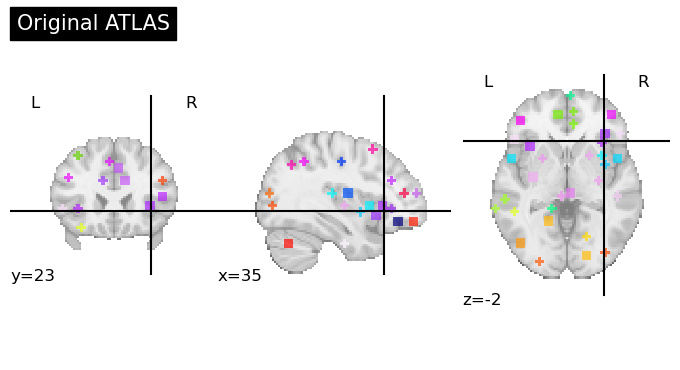

In [25]:
plot_roi(osp.join(ATLAS_DIR,f'{ATLAS_NAME}.nii.gz'),title='Original ATLAS')

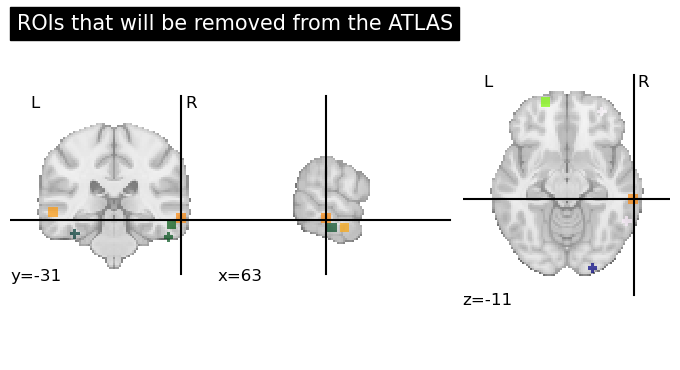

In [26]:
if len(bad_roi_list) > 0:
    plot_roi(osp.join(ATLAS_DIR,f'{ATLAS_NAME}.RemovedROIs.nii.gz'),title='ROIs that will be removed from the ATLAS')

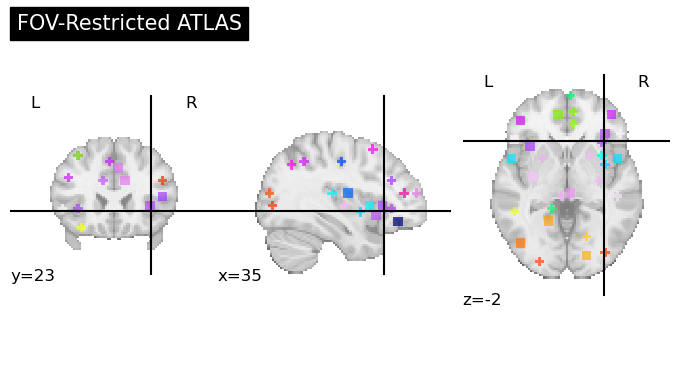

In [27]:
plot_roi(osp.join(ATLAS_DIR,f'rm.{ATLAS_NAME}.fov_restricted.nii.gz'),title='FOV-Restricted ATLAS')

In [28]:
command = f"""ml afni; \
             cd {ATLAS_DIR}; \
             3dRank -overwrite -prefix {ATLAS_NAME}.nii.gz -input rm.{ATLAS_NAME}.fov_restricted.nii.gz;"""
output  = subprocess.check_output(command, shell=True, stderr=subprocess.STDOUT)
print(output.strip().decode())

[+] Loading AFNI current-py3  ... 
AFNI/current-py3 last updated  2025-08-05

++ Output dataset /vf/users/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery/Power264-discovery.nii.gz


# 10. Prepare Files for BrainNetViewer

The first file will be loaded as node

The second file must be loaded in the Node tab within the Options window

In [29]:
nw_list = list(roi_info_df['Network'].unique())
Nw2ID={r:i+1 for i,r in enumerate(nw_list)}

In [30]:
roi_info_df['Node Size'] = 1
roi_info_df['Short ROI Name'] = roi_info_df['ROI_Name']
roi_info_df['Node Color'] = [Nw2ID[n] for n in roi_info_df['Network']]
aux = roi_info_df[['pos_A','pos_R','pos_S','Node Color','Node Size','Short ROI Name']]
aux.to_csv(f'../../../resources/BrainNetViewer/{ATLAS_NAME}.BrainNetViewer_Nodes.node', sep=' ', index=None, header=None)

In [31]:
from matplotlib.colors import hex2color
import numpy as np

In [32]:
c = []
for n in nw_list:
    c = c + [np.array(hex2color(roi_info_df.set_index('Network').loc[n,'RGB'].values[0]))]

In [33]:
c = np.array(c)

In [34]:
np.savetxt(f'../../../resources/BrainNetViewer/{ATLAS_NAME}.BrainNetViewer_Nodes_colors.txt',c, fmt='%0.4f', delimiter=',')